# 이미지 생성 및 평가와 모델 학습 - 과제

---

## 학습 개요

1. **학습 주제**
  - **Text-to-Image 생성과 프롬프트 엔지니어링**: Stable Diffusion 파이프라인을 활용한 이미지 생성 및 프롬프트 설계 기법 이해
  - **멀티모달 평가와 모델 비교**: CLIP 기반 이미지-텍스트 유사도 평가와 CNN(ResNet) 분류 결과 비교 분석
  - **합성 데이터 기반 모델 학습과 Knowledge Distillation**: 생성 이미지로 데이터셋을 구축하여 ResNet Fine-tuning 및 지식 증류 적용

2. **학습 목표**
  - HuggingFace Diffusers 라이브러리를 사용하여 **Stable Diffusion 파이프라인을 로드하고 이미지를 생성**할 수 있다.
  - Positive/Negative 프롬프트를 설계하여 **의도한 컨셉의 이미지를 생성**할 수 있다.
  - CLIP 모델을 활용하여 **이미지와 텍스트 레이블 간 유사도를 측정**하고 결과를 해석할 수 있다.
  - ResNet-50과 CLIP의 분류/평가 결과를 **비교 분석하여 모델 특성의 차이**를 설명할 수 있다.
  - 합성 데이터셋을 구축하고 **ResNet-18을 Fine-tuning**하여 이미지 분류 모델을 학습시킬 수 있다.
  - (선택) Teacher-Student 구조의 **Knowledge Distillation을 구현**하여 Student 모델의 성능을 향상시킬 수 있다.

3. **핵심 개념**
  - **Stable Diffusion**: 텍스트 프롬프트로부터 이미지를 생성하는 확산(diffusion) 기반 생성 모델로, Positive/Negative 프롬프트를 통해 생성 결과를 제어
  - **CLIP (Contrastive Language-Image Pre-training)**: 이미지와 텍스트를 동일한 임베딩 공간에 매핑하여 유사도를 측정하는 멀티모달 모델
  - **ResNet (Residual Network)**: 잔차 연결(skip connection)을 활용한 CNN 아키텍처로, ImageNet 사전학습 가중치를 전이 학습에 활용 가능
  - **Fine-tuning (미세조정)**: 사전학습된 모델의 일부 레이어(주로 분류기)를 새로운 데이터셋에 맞게 재학습하는 전이 학습 기법
  - **Knowledge Distillation (지식 증류)**: 큰 Teacher 모델의 soft label(소프트 확률분포)을 활용하여 작은 Student 모델을 학습시키는 모델 경량화 기법

4. **선행 지식**
  - Python 기본 문법(변수, 함수, 클래스, 반복문)
  - PyTorch 기초(텐서 연산, 모델 정의, 학습 루프)
  - CNN 기본 구조(합성곱, 풀링, 완전연결층)
  - 프롬프트 엔지니어링 기초(키워드 조합, Positive/Negative Prompt)

5. **실습↔과제 연결**
  - 본 과제는 실습(3-2)에서 다룬 **Stable Diffusion → CLIP 평가 → ResNet 비교 → Fine-tuning** 파이프라인을 동일하게 따르되, 주제를 **'클래식 자동차(1960년대 컨버터블)'**로 변경하여 적용하는 **약한 변형(데이터 변화)** 과제입니다.
  - 실습에서 익힌 이미지 생성·평가·학습 워크플로우를 새로운 도메인에 독립적으로 적용하는 능력을 기릅니다.
  - 추가로 **Step 5(선택 과제)**에서는 Knowledge Distillation을 도입하여, ResNet-50(Teacher)의 지식을 ResNet-18(Student)에 전이하는 심화 학습을 수행합니다.

6. **Further Reading**
  - [Stable Diffusion Paper (Rombach et al., 2022)](https://arxiv.org/abs/2112.10752): 잠재 확산 모델(Latent Diffusion Model)의 원리를 설명한 논문으로, Text-to-Image 생성의 핵심 아키텍처를 이해할 수 있습니다.
  - [CLIP Paper (Radford et al., 2021)](https://arxiv.org/abs/2103.00020): 이미지-텍스트 대조 학습의 원리를 다룬 논문으로, 멀티모달 평가의 기반이 되는 모델입니다.
  - [Distilling the Knowledge in a Neural Network (Hinton et al., 2015)](https://arxiv.org/abs/1503.02531): Knowledge Distillation의 원조 논문으로, 소프트 타겟을 활용한 지식 전이 기법을 최초로 제안한 연구입니다.


## 과제 구성

1. **학습 방향**

- **실습 구성 방식**
  - 각 단계별로 TODO 영역을 채우며 학습자가 직접 구현
  - Step 0~4는 필수 과제, Step 5는 선택 과제(Knowledge Distillation)

- **Required Package**
  ```
  python==3.11
  numpy>=2.0.0
  torch>=2.1.0
  torchvision>=0.16.0
  transformers==4.57.1
  diffusers>=0.30.0
  accelerate>=0.30.0
  Pillow>=10.0.0
  hf_transfer>=0.1.9
  ```

- **Step 요약 (총 60분)**
  - **Step 0 (5분)**: HuggingFace Inference API 활용 - Inference API를 사용하여 별도 모델 구동 없이 이미지를 생성하는 방법 이해
  - **Step 1 (10분)**: Text-to-Image 생성 - Stable Diffusion 파이프라인으로 '해안 도로의 1960년대 빨간색 컨버터블' 이미지 생성
  - **Step 2 (10분)**: CLIP 모델을 사용한 생성 이미지 평가 - 생성 이미지와 텍스트 레이블 간 유사도 측정
  - **Step 3 (8분)**: ResNet-50 기반 모델과의 결과 비교 - ImageNet ResNet-50으로 동일 이미지를 분류하고 CLIP 결과와 비교
  - **Step 4 (20분)**: 합성 데이터셋으로 ResNet-18 Fine-tuning - 'brand_new' vs 'rusty_abandoned' 데이터셋 구축 및 모델 학습
  - **Step 5 (선택, 7분)**: Knowledge Distillation - ResNet-50(Teacher)의 지식을 ResNet-18(Student)에 증류

2. **문제 설명**
  - **문제 개요**: 이 과제는 **이미지 파운데이션 모델의 활용과 비교**를 중심으로 설계되었습니다. 학습자는 **Text-to-Image 생성, CLIP 기반 평가, CNN 모델 비교, Fine-tuning**의 전체 워크플로우를 직접 구현하고, 선택적으로 **Knowledge Distillation**까지 확장하여 모델 경량화 기법을 체험할 수 있습니다.

  - **요구사항 요약**
    - **이미지 생성**: Stable Diffusion으로 특정 컨셉('해안 도로의 클래식 카')의 이미지 생성
    - **멀티모달 평가**: CLIP으로 이미지-텍스트 유사도를 측정하여 생성 품질 평가
    - **모델 비교**: ResNet-50과 CLIP의 분류/평가 결과를 비교 분석
    - **Fine-tuning**: 합성 데이터셋을 구축하고 ResNet-18 모델을 학습
    - **(선택) Knowledge Distillation**: Teacher-Student 구조로 지식 증류 수행

3. **학습 문제: Step–TODO 구체 설명**
  - **Step 0 — HuggingFace Inference API 활용 이미지 생성**
    - 코드 실행을 통해 Inference API 기반 이미지 생성 방식을 이해합니다. (TODO 없음)

  - **Step 1 — Text-to-Image 생성**
    - **TODO 1**: Stable Diffusion 파이프라인 로드 *(연결 핵심개념: 모델 로드 / GPU 설정)*
    - **TODO 2**: Positive/Negative 프롬프트 작성 *(연결 핵심개념: 프롬프트 엔지니어링)*
    - **TODO 3**: 이미지 4장 생성 *(연결 핵심개념: 파이프라인 호출 / 파라미터 설정)*
    - **1줄 요약**: Stable Diffusion으로 '1960년대 해안 도로의 빨간색 컨버터블' 이미지를 생성한다.

  - **Step 2 — CLIP 모델을 사용한 생성 이미지 평가**
    - 평가용 텍스트 레이블 작성 (TODO 없음, 코드 실행)
    - **TODO 4**: CLIP 모델을 통한 유사도 점수 및 확률 계산 *(연결 핵심개념: 모델 로드 / 전처리 / logits / softmax)*
    - **1줄 요약**: CLIP을 사용하여 생성 이미지가 의도한 컨셉과 부합하는지 평가한다.

  - **Step 3 — ResNet-50 기반 모델과의 결과 비교**
    - **TODO 5**: ImageNet 사전학습 ResNet-50 로드 및 예측 수행 *(연결 핵심개념: 모델 로드 / 전처리 / 순전파 / softmax)*
    - **1줄 요약**: ResNet-50의 분류 결과와 CLIP의 평가 결과를 비교하여 모델 특성 차이를 확인한다.

  - **Step 4 — 합성 데이터셋으로 ResNet-18 Fine-tuning**
    - **TODO 6**: 클래스별 프롬프트 정의 및 이미지 생성 *(연결 핵심개념: 데이터셋 구축 / 상태 라벨링)*
    - **TODO 7**: ResNet-18 특징 추출부 가중치 고정 및 분류기 레이어 교체 *(연결 핵심개념: 전이 학습 / freeze / fc 교체)*
    - **TODO 8**: 손실 함수 및 옵티마이저 정의, 학습 루프 구현 (10 epoch) *(연결 핵심개념: 학습 설정 / 학습 루프 5단계)*
    - **1줄 요약**: Stable Diffusion으로 생성한 합성 데이터셋으로 ResNet-18을 Fine-tuning하여 자동차 상태를 분류한다.

  - **Step 5 (선택) — Knowledge Distillation**
    - **TODO 9**: Teacher(ResNet-50) 모델 학습 *(연결 핵심개념: Teacher 준비)*
    - **TODO 10**: KD 손실 함수 및 학습 루프 구현 *(연결 핵심개념: KL Divergence / soft label)*
    - Student 모델 평가 (TODO 없음, 코드 실행)
    - **1줄 요약**: ResNet-50 Teacher의 soft label을 활용하여 ResNet-18 Student를 Knowledge Distillation으로 학습시킨다.


## Import & Install

In [1]:
# 공통 실습 환경 설치 (최초 1회 실행)
!pip install -q \
    "numpy>=2.0.0" \
    "torch>=2.1.0" \
    "torchvision>=0.16.0" \
    "transformers==4.57.1" \
    "diffusers>=0.30.0" \
    "accelerate>=0.30.0" \
    "Pillow>=10.0.0" \
    "hf_transfer>=0.1.9"



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# 라이브러리 임포트
import os
import numpy as np
import random
import torch
import torch.nn as nn
import torch.optim as optim
from PIL import Image
from torchvision import transforms, models
from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder
from IPython.display import display

# 시드 고정
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)
np.random.seed(42)
random.seed(42)

# CuDNN 관련 설정 (GPU 연산의 재현성을 위함)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# 장치 설정
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("사용 중인 장치:", device)


사용 중인 장치: cuda


## Step 0: HuggingFace Inference API 활용 이미지 생성

### Concept Check

#### HuggingFace Inference API란?

HuggingFace의 Inference API를 사용하면 별도의 모델 구동 없이 이미지를 생성할 수 있습니다. 개인용 Read API 키 발급에 문제가 있다면, 진행하지 않으셔도 좋습니다.

**Pipeline 방식과의 비교:**
- Inference API는 사용 난이도가 낮고 GPU 연산이 필요하지 않지만, 제어할 수 있는 부분이 적어 커스터마이징이 어렵습니다.
- Pipeline 방식은 로컬에서 모델을 직접 실행하므로, 파라미터를 세밀하게 조절할 수 있습니다.

```python
from huggingface_hub import InferenceClient
import huggingface_hub

# https://huggingface.co/settings/tokens 에서 Read 권한으로 Token을 발급받고, 해당 토큰을 아래에 넣어서 확인할 수 있습니다.
api_key = ''
prompt = 'A photorealistic 1960s red convertible on a coastal road at sunset.'
client = InferenceClient(
    provider="nebius",
    api_key=api_key,
)


# output is a PIL.Image object
image = client.text_to_image(
    prompt,
    model="black-forest-labs/FLUX.1-dev",
)
display(image)
```

## Step 1: Text-to-Image 생성

### Concept Check

#### Stable Diffusion 파이프라인

이번 과제는 지난 실습과 비슷하게 HuggingFace의 `diffusers` 라이브러리를 사용하여 Stable Diffusion 파이프라인을 로드하고, **'해안 도로의 클래식 카'**를 주제로 이미지를 생성합니다.

오늘은 모델에게 Positive/Negative 프롬프트를 통해 조절해볼 계획입니다.
- **Positive Prompt**: 생성하고 싶은 이미지(자동차 모델/시대, 색상, 배경, 분위기 등)를 상세히 기술합니다.
- **Negative Prompt**: 생성 이미지에서 제외하고 싶은 요소(예: 만화 스타일, 흐릿함, 왜곡 등)를 기술합니다.

**주요 파라미터:**
- `guidance_scale`: 프롬프트에 대한 모델의 충실도 조절 (높을수록 프롬프트에 충실)
- `num_inference_steps`: 디노이징 스텝 수 (높을수록 품질 향상, 시간 증가)
- `num_images_per_prompt`: 한 번에 생성할 이미지 수

### TODO 1: Stable Diffusion 파이프라인 로드

Stable Diffusion 파이프라인을 로드하고 GPU로 이동시킵니다.

**요구사항:** `StableDiffusionPipeline.from_pretrained`을 사용하여 `runwayml/stable-diffusion-v1-5` 모델을 로드하세요
1. 메모리 효율을 위해 `torch_dtype`을 `torch.float16`으로 설정하세요
2. 파이프라인을 GPU(device)로 이동시키세요

In [3]:
# Stable Diffusion 파이프라인을 로드하고 GPU로 이동시키는 코드를 작성하세요.
import torch
from diffusers import StableDiffusionPipeline

model_id = "runwayml/stable-diffusion-v1-5"
pipe = StableDiffusionPipeline.from_pretrained(model_id, torch_dtype=torch.float16)
pipe = pipe.to(device)

model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

c:\Users\SSAFY\AppData\Local\Programs\Python\Python312\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\SSAFY\.cache\huggingface\hub\models--runwayml--stable-diffusion-v1-5. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


config.json:   0%|          | 0.00/617 [00:00<?, ?B/s]

...

config.json:   0%|          | 0.00/547 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.22G [00:00<?, ?B/s]

diffusion_pytorch_model.safetensors:   0%|          | 0.00/335M [00:00<?, ?B/s]

diffusion_pytorch_model.safetensors:   0%|          | 0.00/3.44G [00:00<?, ?B/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

### TODO 2: Positive/Negative 프롬프트 작성

'해질녘 해안 도로를 달리는 1960년대 빨간색 컨버터블'을 주제로 프롬프트를 작성합니다.

**요구사항:**
1. `positive_prompt`를 작성하세요 — 'photorealistic', '1960s', 'convertible', 'coastal road', 'sunset' 등의 키워드를 활용
2. `negative_prompt`를 작성하세요 — 만화 스타일, 저품질, 왜곡 등 제외할 요소를 기술

In [4]:
positive_prompt = "photorealistic photo of a red 1960s convertible sports car driving on a coastal road during sunset, cinematic lighting, high detail"
negative_prompt = "cartoon, drawing, sketch, blurry, low quality, deformed, text, watermark, modern car"

### TODO 3: 이미지 4장 생성

**요구사항:** `pipe` 객체를 통해 위에서 작성한 두 프롬프트를 활용하여 이미지를 4장 생성합니다.
   1. `guidance_scale`, `num_inference_steps`, `num_images_per_prompt` 인자를 적절히 설정하세요

  0%|          | 0/20 [00:00<?, ?it/s]

--- 생성된 이미지 --- 


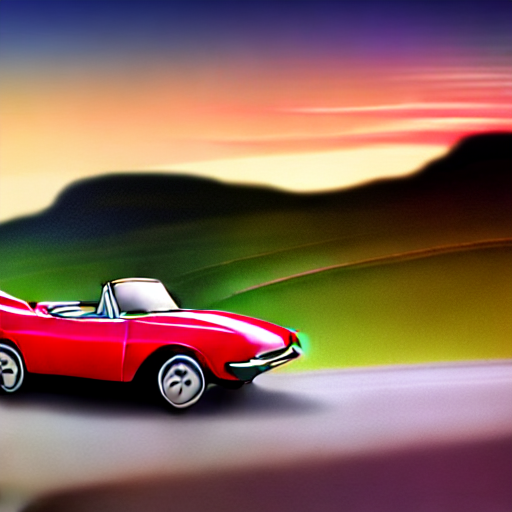

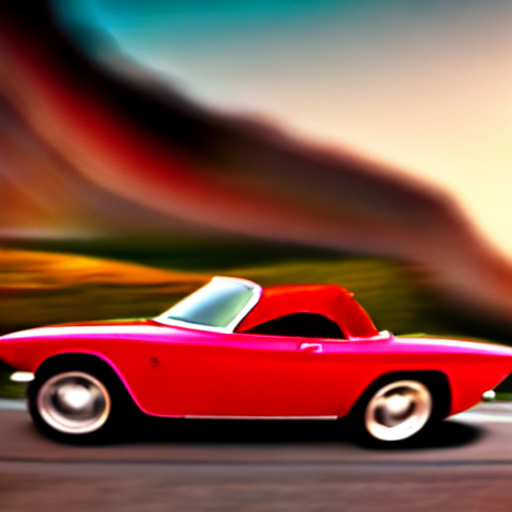

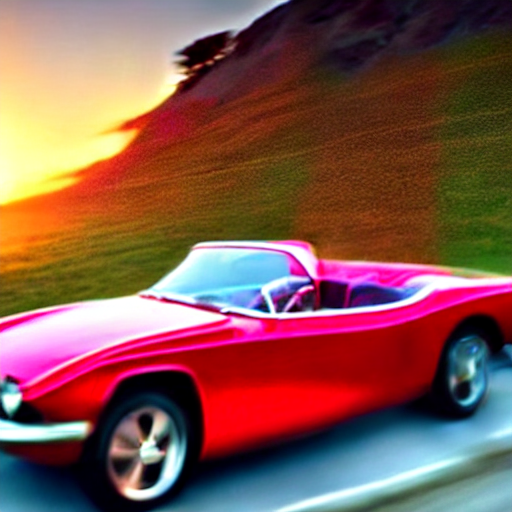

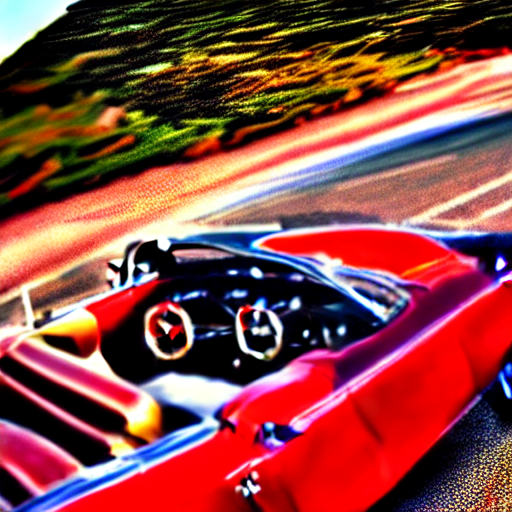

In [6]:
# 이미지를 4장 생성하는 코드를 작성하세요.
result = pipe(
    positive_prompt,
    guidance_scale=20,
    num_inference_steps=20,
    num_images_per_prompt=4
)
images = result.images

print("--- 생성된 이미지 --- ")
for i, img in enumerate(images):
    img.save(f"generated_car_image_{i}.png")
    display(img)

## Step 2: CLIP 모델을 사용한 생성 이미지 평가

### Concept Check

#### CLIP 모델이란?

CLIP(Contrastive Language-Image Pre-training)은 이미지와 텍스트를 **동일한 임베딩 공간**에 매핑하여 유사도를 측정하는 멀티모달 모델입니다.

방금 생성한 이미지 중 하나가 의도한 컨셉과 얼마나 잘 부합하는지 CLIP 모델로 평가합니다. 생성된 '클래식 카' 이미지를 올바르게 설명하는 **정답 레이블**과, **시대/스타일/배경**이 다른 **오답 레이블**들을 직접 정의하여 모델의 이해도를 확인합니다.

**CLIP 평가의 핵심:**
- 이미지와 여러 텍스트 레이블을 입력하면, 각 레이블과의 유사도를 확률로 계산
- 정답 레이블이 가장 높은 확률을 가지면, 생성 이미지가 의도한 컨셉에 부합한다고 판단

**평가용 텍스트 레이블 작성**

생성된 이미지를 평가하기 위한 텍스트 레이블을 작성합니다. 다음은 정답 레이블(1960년대, 컨버터블, 해안도로)과 오답 레이블(다른 시대, 차종, 스타일, 배경)을 포함하여 4개 이상의 레이블입니다.

In [7]:
from PIL import Image
from transformers import CLIPProcessor, CLIPModel

image = Image.open("generated_car_image_0.png")

labels = [
    "a photo of a 1960s red convertible on a coastal road", # 정답
    "a photo of a modern red sedan in a city",              # 오답 1: 다른 시대, 차종, 배경
    "a sketch of a classic red car",                        # 오답 2: 다른 스타일
    "a photo of a red convertible in a forest"              # 오답 3: 다른 배경
]

### TODO 4: CLIP 모델을 통한 유사도 점수 및 확률 계산

CLIP 모델과 프로세서를 로드합니다.

**요구사항:**
1. 모델 ID `openai/clip-vit-base-patch32`를 사용하여 `CLIPProcessor`와 `CLIPModel`을 로드하세요
2. 이미지와 텍스트 레이블을 CLIP 모델에 입력할 수 있도록 전처리합니다. `processor`를 사용하여 `text`와 `images`를 함께 전처리하고, 결과를 PyTorch 텐서로 받으세요
3. 전처리된 입력을 CLIP 모델에 통과시켜 유사도 점수(logits)와 확률을 계산합니다.
   1. `torch.no_grad()` 블록 안에서 모델을 실행하세요
   2. 결과에서 `logits_per_image`를 추출한 뒤 `softmax`를 적용하세요

In [13]:
# 1. 모델 ID `openai/clip-vit-base-patch32`를 사용하여 `CLIPProcessor`와 `CLIPModel`을 로드하세요
clip_model_id = "openai/clip-vit-base-patch32"
processor = CLIPProcessor.from_pretrained(clip_model_id)
model_clip = CLIPModel.from_pretrained(clip_model_id).to(device)

# 2. 이미지와 텍스트 레이블을 CLIP 모델에 입력할 수 있도록 전처리합니다.
# `processor`를 사용하여 `text`와 `images`를 함께 전처리하고, 결과를 PyTorch 텐서로 받으세요
inputs = processor(text=labels, images=image, return_tensors="pt", padding = True).to(device)

# 3. 전처리된 입력을 CLIP 모델에 통과시켜 유사도 점수(logits)와 확률을 계산합니다.
with torch.no_grad():
    outputs = model_clip(**inputs)
    logits_per_image = outputs.logits_per_image
    probs = logits_per_image.softmax(dim=1)

# 예측 결과가 제일 높은 이미지를 확인해봅시다.
best_idx = logits_per_image.argmax(dim=1).item()
print(f"CLIP 예측 결과: '{labels[best_idx]}' 라벨이 가장 타당하다고 예측되었습니다.")
print("\n--- 각 레이블 별 확률 --- ")
for i, label in enumerate(labels):
    print(f"{label}: {probs[0][i].item():.4f}")

CLIP 예측 결과: 'a sketch of a classic red car' 라벨이 가장 타당하다고 예측되었습니다.

--- 각 레이블 별 확률 --- 
a photo of a 1960s red convertible on a coastal road: 0.1972
a photo of a modern red sedan in a city: 0.0041
a sketch of a classic red car: 0.5604
a photo of a red convertible in a forest: 0.2383


## Step 3: ResNet-50 기반 모델과의 결과 비교

### Concept Check

#### CLIP vs ResNet-50 비교

동일한 클래식 카 이미지를 전통적인 CNN 분류 모델인 ResNet-50으로 분류하고, CLIP의 결과와 비교합니다.

- **ResNet-50**: ImageNet 카테고리(예: 'convertible', 'sports car')로 예측하며, 주로 이미지의 핵심 객체 자체에 집중합니다.
- **CLIP**: '1960년대', '해안 도로', '해질녘'과 같은 문맥 정보까지 이해하여 평가합니다.

이 차이를 직접 확인해보세요.

### TODO 5: ImageNet 사전학습 ResNet-50 로드

**요구사항:**
1. ImageNet으로 사전 학습된 ResNet-50 모델을 로드합니다.
   1. `models.resnet50` 함수와 `weights` 인자를 사용하여 모델을 로드하세요
   2. `.eval()`을 호출하여 평가 모드로 설정하세요
2. 이미지를 ResNet-50에 맞게 전처리하는 코드를 작성해주세요. 그리고 `img_tensor`에 이미지를 변환하여 할당해주세요.
   1. (256, 256) 사이즈로 리사이즈
   2. (224, 224) 사이즈로 CenterCrop
   3. Tensor로 변환
   4. 정규화 수행 (평균: `[0.485, 0.456, 0.406]`, 표준편차: `[0.229, 0.224, 0.225]`)
3. 전처리된 이미지 텐서로 ResNet-50 예측을 수행합니다.
   1. `torch.no_grad()` 블록 안에서 모델을 실행하세요
   2. 결과에 `softmax` 함수를 적용하여 확률 값을 계산하세요

In [ ]:
# 1. ImageNet으로 사전 학습된 ResNet-50 모델을 로드합니다.
from torchvision import models
resnet50 = None


imagenet_classes = models.ResNet50_Weights.IMAGENET1K_V2.meta["categories"]

# 2. 이미지를 ResNet-50에 맞게 전처리하는 코드를 작성해주세요.
preprocess = None
img_tensor = None

# 3. 전처리된 이미지 텐서로 ResNet-50 예측을 수행합니다.
with torch.no_grad():
    output = None
    probs_resnet = None

print("--- ResNet-50 Top-5 예측 결과 ---")
top5_prob, top5_idx = torch.topk(probs_resnet, 5)
for i in range(top5_prob.size(0)):
    class_idx = top5_idx[i].item()
    class_name = imagenet_classes[class_idx]
    probability = top5_prob[i].item()
    print(f"{i+1}. 클래스: {class_name} (인덱스: {class_idx}), 확률: {probability:.4f}")

## Step 4: 합성 데이터셋으로 ResNet-18 Fine-tuning

### Concept Check

#### 합성 데이터 기반 전이 학습

이제 과제의 핵심 단계로, Stable Diffusion을 이용해 **동일한 자동차의 두 가지 다른 '상태'**를 표현하는 합성 데이터셋을 구축합니다.

- **'아주 깨끗한 새 차 (brand_new)'**: 해안 도로를 달리는 showroom 컨디션의 반짝이는 새 차
- **'오래되어 녹슨 폐차 (rusty_abandoned)'**: 같은 자동차가 시간 경과로 녹슬고 버려진 상태

이 두 클래스의 이미지를 생성하여, 자동차의 상태를 분류하는 모델을 Fine-tuning합니다.

**Fine-tuning 전략:**
- 사전학습된 ResNet-18의 특징 추출부(convolutional layers)는 가중치를 고정(freeze)
- 분류기(fully connected layer)만 새로운 2클래스 데이터셋으로 학습

Step 3에서 사용한 ResNet-50보다 조금 더 가벼운 ResNet-18을 활용합니다.


### TODO 6: 클래스별 프롬프트 정의 및 이미지 생성

**'새 차'**와 **'녹슨 폐차'** 클래스에 대한 프롬프트를 정의하고 학습/테스트 이미지를 생성합니다.

**요구사항:**
1. 두 클래스 모두 공통으로 `'1960s red convertible'`, `'coastal road'` 조건을 포함하고, 상태 키워드만 변경하세요  
   - `brand_new`: 'brand new', 'shiny', 'pristine'  
   - `rusty_abandoned`: 'rusty', 'abandoned', 'wrecked'
2. 각 클래스별로 학습 이미지 5장, 테스트 이미지 3장을 생성 후 저장해주세요.


In [ ]:
import os
from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder

# 1. 각 클래스에 대한 프롬프트를 정의하세요.
# 가능하다면 negative prompt도 활용해보세요.
classes = {
    "brand_new": None,
    "rusty_abandoned": None
}
neg_prompt_ft = None

# 학습 및 테스트 데이터 폴더 생성
for split in ['train', 'test']:
    for cls in classes.keys():
        os.makedirs(f"data/{split}/{cls}", exist_ok=True)

# 2. 각 클래스별로 학습 이미지 5장, 테스트 이미지 3장을 생성 후 저장해주세요.
for split in ['train', 'test']:
    num_images = 5 if split == 'train' else 3
    for cls, prompt in classes.items():
        print(f"--- Generating {split} images for {cls}... ---")
        result = None
        images = result.images
        for i, img in enumerate(images):
            img.save(f"data/{split}/{cls}/{cls}_{split}_{i}.png")
            display(img)


# 데이터셋 및 데이터로더 생성 (수정 불필요)
train_transforms = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])
test_transforms = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])
train_dataset = ImageFolder("data/train", transform=train_transforms)
test_dataset = ImageFolder("data/test", transform=test_transforms)
train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=4, shuffle=False)
print(f"\n총 학습 이미지: {len(train_dataset)}, 총 테스트 이미지: {len(test_dataset)}")
print(f"클래스: {train_dataset.classes}")

### TODO 7: ResNet-18 특징 추출부 가중치 고정 및 분류기 레이어 교체

**요구사항:**
1. 사전학습된 ResNet-18 모델을 불러와 특징 추출부의 가중치를 고정합니다. (지난 3-1 실습/과제 참고)
2. 모델의 마지막 레이어(fc)를 우리 데이터셋의 클래스 수에 맞게 새로운 `nn.Linear` 레이어로 교체합니다.
   1. `model_ft.fc.in_features`로 입력 뉴런 수를 가져오세요
   2. `len(train_dataset.classes)`로 출력 뉴런 수를 설정하세요

In [ ]:
# 1. 사전학습된 ResNet-18 모델을 불러와 특징 추출부의 가중치를 고정합니다. (지난 3-1 실습/과제 참고)
model_ft = None
for param in ...:
    
# 2. 모델의 마지막 레이어(fc)를 우리 데이터셋의 클래스 수에 맞게 새로운 `nn.Linear` 레이어로 교체합니다.
num_features = model_ft.fc.in_features
model_ft.fc = None
model_ft = model_ft.to(device)

### TODO 8: 손실 함수 및 옵티마이저 정의

**요구사항:**
1. `nn.CrossEntropyLoss()`를 손실 함수로 정의하세요
2. `optim.SGD`를 옵티마이저로 정의하세요 — 학습할 파라미터는 `model_ft.fc.parameters()`만 지정
3. 10 에포크(epoch) 동안 모델을 학습시키는 전체 학습 루프를 구현하세요.
   - 기울기 초기화 (`optimizer.zero_grad()`)
   - 순전파 (`outputs = model_ft(inputs)`)
   - 손실 계산 (`loss = criterion(outputs, labels)`)
   - 역전파 (`loss.backward()`)
   - 가중치 업데이트 (`optimizer.step()`)


In [ ]:
# 1. `nn.CrossEntropyLoss()`를 손실 함수로 정의하세요
criterion = None

# 2. `optim.SGD`를 옵티마이저로 정의하세요 — 학습할 파라미터는 `model_ft.fc.parameters()`만 지정
optimizer = None

# 3. 10 에포크(epoch) 동안 모델을 학습시키는 전체 학습 루프를 구현하세요.
model_ft.train()
num_epochs = 10

print("\n--- Fine-tuning 시작 ---")
for epoch in range(num_epochs):
    running_loss = 0.0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        # 1. 기울기 초기화
        
        # 2. 순전파
        
        # 3. 손실 계산
        
        # 4. 역전파
        
        # 5. 가중치 업데이트
        

        running_loss += loss.item() * inputs.size(0)

    epoch_loss = running_loss / len(train_dataset)
    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {epoch_loss:.4f}")
print("--- Fine-tuning 완료 ---")

학습이 완료된 모델을 테스트 데이터셋으로 평가하여 자동차의 상태('새 차' vs '녹슨 폐차')를 얼마나 잘 분류하는지 정확도를 확인합니다.

In [ ]:
# 모델 평가 코드 (수정 불필요)
model_ft.eval()
correct = 0
total = 0
print("\n--- 테스트 시작 ---")
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model_ft(inputs)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        # 예측 결과 일부 시각화
        for i in range(inputs.size(0)):
            print(f"예측: {test_dataset.classes[predicted[i]]}, 정답: {test_dataset.classes[labels[i]]}")

print(f'\n테스트 데이터셋에서 모델 정확도: {100 * correct / total:.2f} %')

## Step 5: Knowledge Distillation (선택 과제)

### Concept Check

#### Knowledge Distillation(지식 증류)이란?

Knowledge Distillation은 큰 모델(Teacher)이 학습한 "지식"을 작은 모델(Student)에게 전달하는 기법입니다. Teacher 모델의 **soft label**(소프트맥스 확률분포)에는 클래스 간 관계 정보가 담겨 있어, 단순한 hard label(0 또는 1)보다 풍부한 학습 신호를 제공합니다.

예를 들어 Teacher가 어떤 이미지에 대해 `[brand_new: 0.9, rusty_abandoned: 0.1]`이라고 예측했다면, 이 "0.1"에도 "이 이미지에 약간의 노후 요소가 있다"는 의미 있는 정보가 담겨 있습니다.

#### Teacher-Student 구조

```
[Teacher: ResNet-50]          [Student: ResNet-18]
   (큰 모델, 동결)                (작은 모델, 학습 대상)
        │                              │
        ▼                              ▼
   soft label 생성     ──────▶    KD Loss로 학습
   (softmax with T)               (CE + KL Divergence)
```

#### KD 손실 함수

Knowledge Distillation의 손실 함수는 두 가지 손실의 가중합으로 구성됩니다:

```
KD_Loss = alpha * T^2 * KL_Divergence(student_soft, teacher_soft) + (1 - alpha) * CE_Loss(student_hard, true_label)
```

- **KL Divergence Loss**: Student의 soft prediction과 Teacher의 soft label 간 분포 차이
  - Temperature `T`로 softmax를 부드럽게 만들어 클래스 간 관계 정보를 극대화
  - `T^2`를 곱하는 이유: Temperature로 나눈 softmax의 gradient 크기를 보정
- **Cross-Entropy Loss**: Student의 prediction과 실제 정답(hard label) 간 손실
- **alpha**: 두 손실의 비중을 조절하는 하이퍼파라미터 (0~1)

### TODO 9: Teacher(ResNet-50) 모델 학습

Knowledge Distillation을 위해 먼저 Teacher 모델(ResNet-50)을 동일한 데이터셋으로 학습시킵니다.

**요구사항:**
1. ImageNet 사전학습된 ResNet-50을 로드하세요
2. 특징 추출부를 동결(freeze)하고 fc층을 2클래스로 교체하세요
3. 위에서 정의한 Teacher Model을 10 epoch동안 학습시켜주세요.
   1. 손실함수와 Optimizer를 구현해주세요. 학습을 위한 하이퍼파라미터는 자유롭게 설정해주세요.
   2. 학습루프를 구성해주세요.

In [ ]:
# 1. ImageNet 사전학습된 ResNet-50을 로드하세요
teacher_model = None
for param in ...:
    

# 2. 특징 추출부를 동결(freeze)하고 fc층을 2클래스로 교체하세요
num_features_teacher = teacher_model.fc.in_features
teacher_model.fc = None
teacher_model = teacher_model.to(device)

# 3. 위에서 정의한 Teacher Model을 10 epoch동안 학습시켜주세요.
# 3.1 손실함수와 Optimizer를 구현해주세요. 학습을 위한 하이퍼파라미터는 자유롭게 설정해주세요.
teacher_criterion = None
teacher_optimizer = None

teacher_model.train()
num_epochs_teacher = 10

print("--- Teacher (ResNet-50) Fine-tuning 시작 ---")
for epoch in range(num_epochs_teacher):
    running_loss = 0.0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        # 3.2 학습루프를 구성해주세요.
        
        
        
        
        

        running_loss += loss.item() * inputs.size(0)
    epoch_loss = running_loss / len(train_dataset)
    print(f"Epoch {epoch+1}/{num_epochs_teacher}, Loss: {epoch_loss:.4f}")


# Teacher 평가
teacher_model.eval()
correct = 0
total = 0
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = teacher_model(inputs)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
print(f"\nTeacher 모델 테스트 정확도: {100 * correct / total:.2f} %")
print("--- Teacher Fine-tuning 완료 ---")

### TODO 10: KD 손실 함수 및 학습 루프 구현

Knowledge Distillation 손실 함수를 정의하고, Student 모델(ResNet-18)을 Teacher의 soft label로 학습시킵니다.

**요구사항:**
1. Student 모델(ResNet-18)을 새로 초기화하세요 (fc층만 2클래스로 교체)
2. 10 epoch 동안 KD 학습을 수행하세요
   1. Student 모델은 Teacher 모델의 결과를 학습합니다 (`soft_label`)
   2. 손실은 Cross Entropy와 KD 손실 함수를 통해 학습해주세요. `F.kl_div(student_log_softmax, teacher_softmax) * alpha * T^2 + CE_loss * (1 - alpha)`. 두 손실을 공식에 맞춰 합한 후 `.backward()`를 수행하면 됩니다.

**참고:**
- Temperature `T`는 소프트맥스를 부드럽게 만드는 파라미터입니다 (보통 2~20 사이)
- `alpha`는 KL Loss와 CE Loss의 비중을 조절합니다 (보통 0.5~0.9)
- Teacher 모델은 반드시 `eval()` 모드로, `torch.no_grad()`로 gradient 차단

In [ ]:
import torch.nn.functional as F

# KD 하이퍼파라미터 (아래 학습 루프에서 활용)
T = 4.0       # Temperature
alpha = 0.7   # KL Loss 비중

# 1. Student 모델(ResNet-18)을 새로 초기화하세요 (fc층만 2클래스로 교체)
student_model = None
for param in ...:
    

num_features_student = student_model.fc.in_features
student_model.fc = None
student_model = student_model.to(device)

# 2. 10 epoch 동안 KD 학습을 수행하세요
student_optimizer = None
ce_criterion = None

teacher_model.eval()  # Teacher는 반드시 eval 모드
student_model.train()
num_epochs_kd = 10

print("--- Knowledge Distillation 학습 시작 ---")
for epoch in range(num_epochs_kd):
    running_loss = 0.0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        # Teacher의 soft label 생성 (gradient 불필요)
        with torch.no_grad():
            teacher_logits = None
            teacher_soft = None

        # Student의 예측
        student_logits = None
        student_log_soft = None

        # KD Loss 계산
        kl_loss = None
        ce_loss = None
        loss = None

        # 역전파 및 가중치 업데이트




        running_loss += loss.item() * inputs.size(0)

    epoch_loss = running_loss / len(train_dataset)
    print(f"Epoch {epoch+1}/{num_epochs_kd}, KD Loss: {epoch_loss:.4f}")
print("--- Knowledge Distillation 학습 완료 ---")

In [ ]:
student_model.eval()
correct = 0
total = 0
print("\n--- KD Student 모델 테스트 시작 ---")
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = student_model(inputs)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        for i in range(inputs.size(0)):
            print(f"예측: {test_dataset.classes[predicted[i]]}, 정답: {test_dataset.classes[labels[i]]}")

student_accuracy = 100 * correct / total
print(f'\nKD Student 모델 테스트 정확도: {student_accuracy:.2f} %')
print("\n--- 결과 비교 ---")
print(f"Step 4 기본 ResNet-18 (CE Loss만 학습): 이전 결과 참고")
print(f"Step 5 KD Student ResNet-18 (Teacher soft label 활용): {student_accuracy:.2f} %")
print("\nKnowledge Distillation을 통해 Teacher의 지식이 Student에게 전달되었습니다.")

## 학생용 자가 체크리스트

- [ ] **이미지 생성**: Stable Diffusion 파이프라인을 로드하고, Positive/Negative 프롬프트를 설계하여 의도한 컨셉의 이미지를 생성할 수 있다.
- [ ] **CLIP 평가**: CLIP 모델을 사용하여 이미지와 텍스트 레이블 간 유사도를 측정하고, 결과를 해석할 수 있다.
- [ ] **모델 비교**: ResNet-50과 CLIP의 분류/평가 결과를 비교하여, 멀티모달 모델과 CNN 모델의 특성 차이를 설명할 수 있다.
- [ ] **데이터셋 구축**: Stable Diffusion으로 특정 클래스의 합성 이미지 데이터셋을 구축할 수 있다.
- [ ] **Fine-tuning**: 사전학습된 ResNet-18의 fc층을 교체하고, 합성 데이터셋으로 학습 루프를 구현할 수 있다.
- [ ] **(선택) Knowledge Distillation**: Teacher 모델의 soft label을 활용하여 Student 모델을 학습시키는 Knowledge Distillation 과정을 이해하고 구현할 수 있다.

### **Content License Agreement**

<font color='red'><b>**WARNING**</b></font> : 본 자료는 삼성청년SW·AI아카데미의 컨텐츠 자산으로, 보안서약서에 의거하여 어떠한 사유로도 임의로 복사, 촬영, 녹음, 복제, 보관, 전송하거나 허가 받지 않은 저장매체를 이용한 보관, 제3자에게 누설, 공개 또는 사용하는 등의 무단 사용 및 불법 배포 시 법적 조치를 받을 수 있습니다.